In [9]:
subject_id = 127 # or whatever subject you're working with

In [10]:
import mne
import numpy as np
from spectral.epochs import create_epochs, get_reject_log
from spectral.utils import ProjectPaths, print_timestamp, load_config

# raw_annotated = raw_pyprep.copy()
paths = ProjectPaths(subject_id)
fname = paths.preprocessed / f"sub-{subject_id}_annotated_filtered_raw.fif"

if not fname.exists():
    raise FileNotFoundError(f"Could not find preprocessed file: {fname}")

raw_annotated = mne.io.read_raw_fif(fname, preload=True)

Opening raw data file /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-127/preprocessed/sub-127_annotated_filtered_raw.fif...
    Range : 0 ... 79375 =      0.000 ...   317.500 secs
Ready.
Reading 0 ... 79375  =      0.000 ...   317.500 secs...


Setting 6251 of 77876 (8.03%) samples to NaN, retaining 71625 (91.97%) samples.


Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


/Users/daniel/PhD/Projects/psd-paths/.venv/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


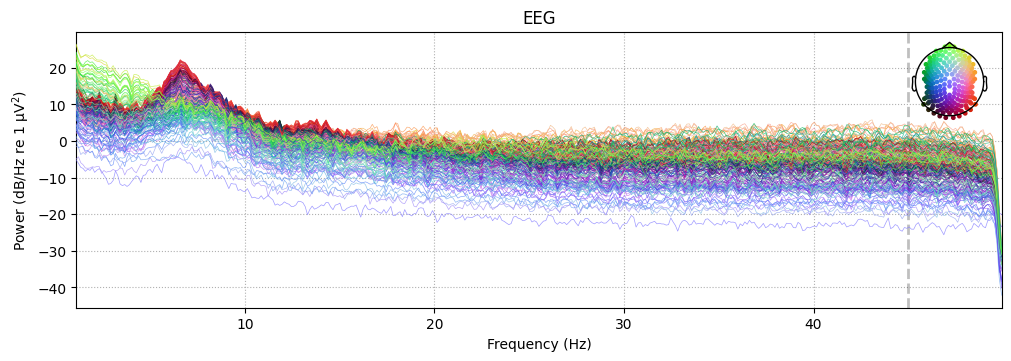

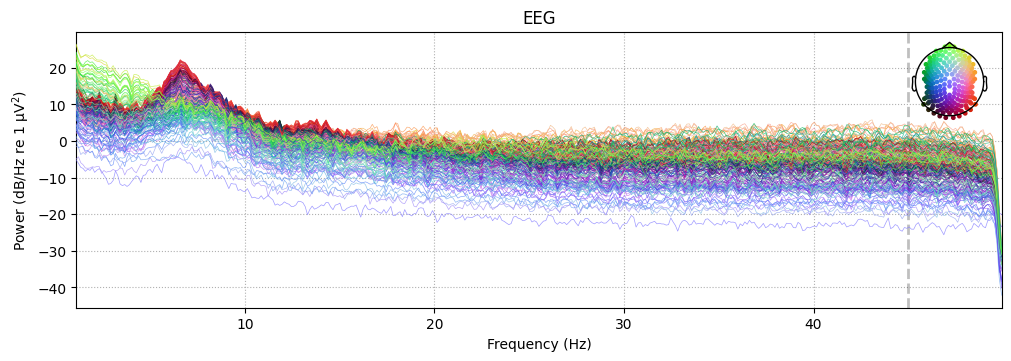

In [11]:
total_duration = raw_annotated.times[-1]

raw_annotated.crop(tmin=3.0, tmax=total_duration - 3, include_tmax=True).compute_psd(fmin=1, fmax=50, picks="eeg", exclude="bads").plot(spatial_colors=True)

Not setting metadata
88 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 88 events and 1251 original time points ...
1 bad epochs dropped
fitting finished
Dropped 87 epochs: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86


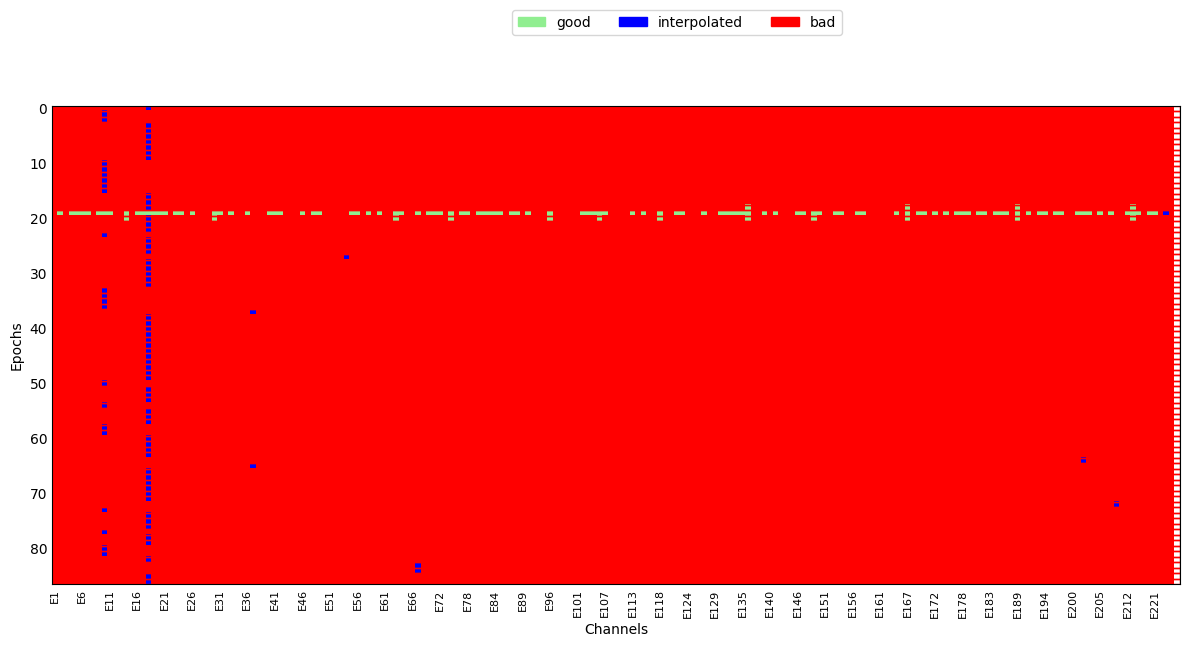

Additional 204 bad channels found:['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E54', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E68', 'E69', 'E70', 'E71', 'E72', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E89', 'E90', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E100', 'E101', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129', 'E130', 'E131', 'E132', 'E134', 'E135', 'E136', 'E137', 'E138', 'E139', 'E140', 'E141', 'E142', 'E14

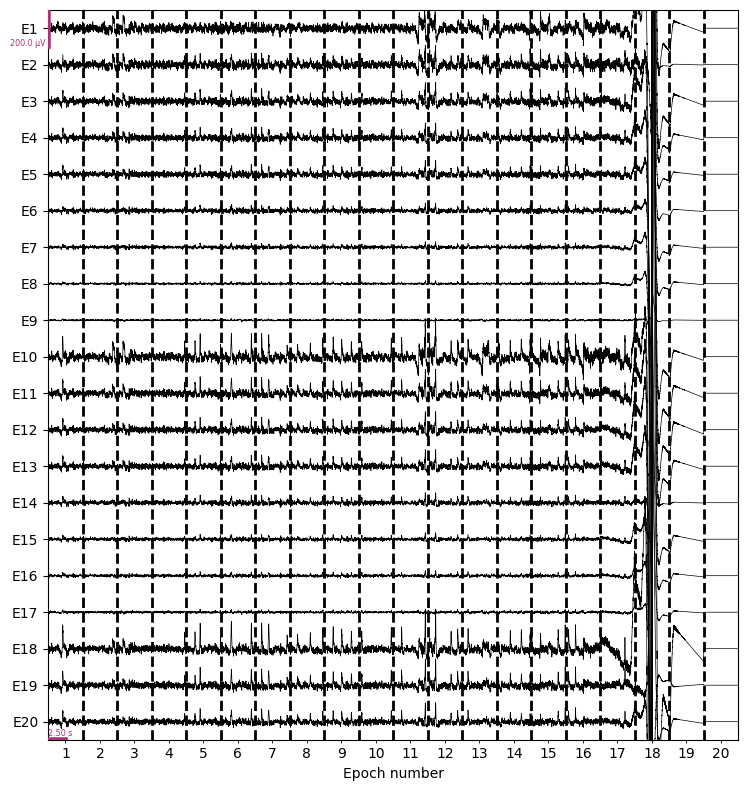

In [12]:


epochs = create_epochs(raw_annotated, overlap=1.5, reject_by_annotation = False)

reject_log = get_reject_log(epochs, resample=125, n_interpolate=[1], consensus=[0.35])
reject_plot = reject_log.plot("vertical")


# Drop channels with more than 40% bad epochs
BADS_THRESHOLD = 0.40

bads = np.logical_or(reject_log.labels == 1, reject_log.labels == 2)

bad_channel = bads.mean(axis=0)
# print(bad_channel)
epochs.info
channel_names = epochs.info["ch_names"]
bad_channels_by_epochs = [
    name for name, value in zip(channel_names, bad_channel) if value > BADS_THRESHOLD
]
print(
    f"Additional {len(bad_channels_by_epochs)} bad channels found:{
        bad_channels_by_epochs
    }"
)

#epochs.info["bads"].extend(bad_channels_by_epochs)
try:
    bad_channel_plot_additional = epochs.plot(
        picks=bad_channels_by_epochs,
        scalings=dict(eeg=1e-4),
        show_scrollbars=False,
    )
except Exception as e:
    print(f"An error occurred: {e}")

Effective window size : 5.004 (s)
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/var/folders/xq/sl7xjp_95qx7wfngy6s6vvg00000gn/T/ipykernel_22208/3738686481.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


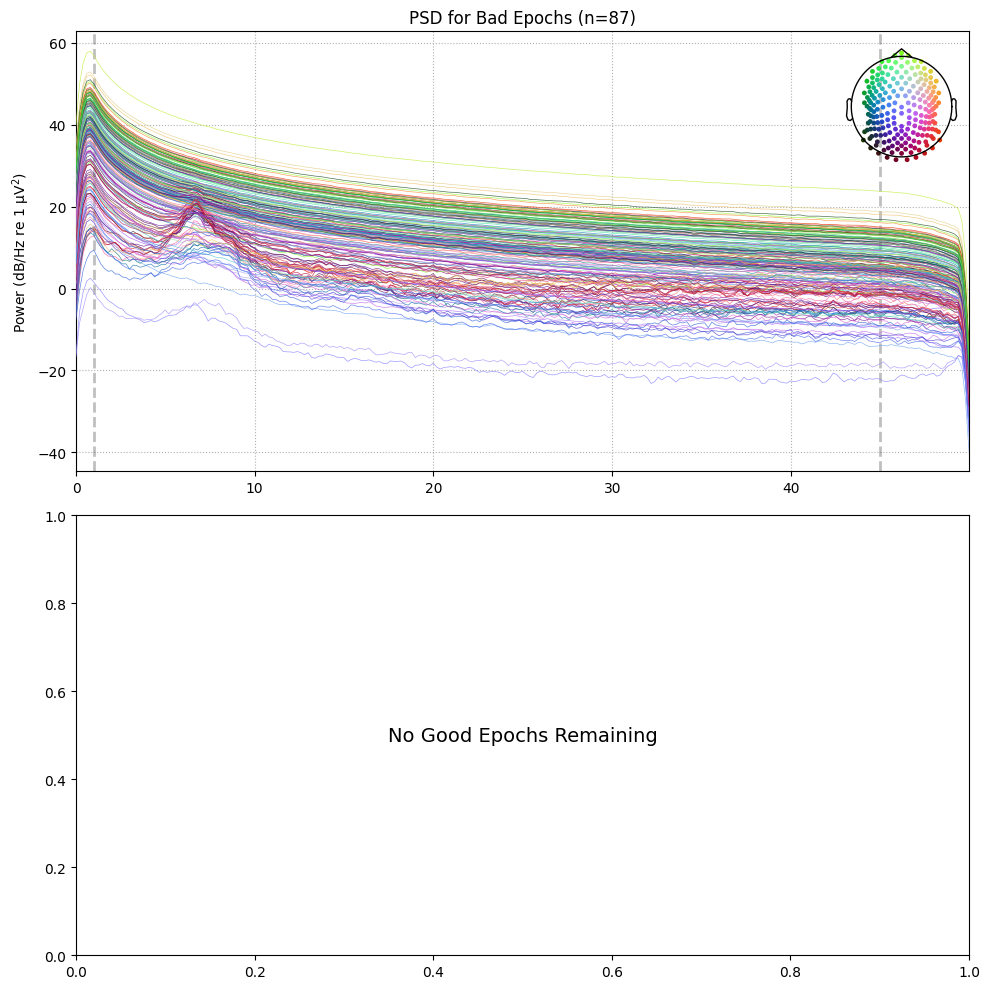

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Determine if we have any bad epochs
n_bad_epochs = np.sum(reject_log.bad_epochs)
n_good_epochs = np.sum(~reject_log.bad_epochs)

# Create the figure
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# 2. Plot Bad Epochs (with Safeguard)
if n_bad_epochs > 0:
    epochs[reject_log.bad_epochs].compute_psd(
        method="welch", picks="eeg", fmax=50.0, exclude="bads"
    ).plot(
        average=False, picks="eeg", exclude="bads", show=False,
        amplitude=False, axes=axs[0]
    )
    axs[0].set_title(f"PSD for Bad Epochs (n={n_bad_epochs})")
else:
    # Handle the case where no epochs were dropped
    axs[0].text(0.5, 0.5, 'No Bad Epochs Dropped', 
                ha='center', va='center', fontsize=14)
    axs[0].set_title("PSD for Bad Epochs (None)")
    # Set dummy limits so the ylim comparison doesn't fail
    axs[0].set_ylim(0, 1) 

# 3. Plot Good Epochs (with Safeguard)
if n_good_epochs > 0:
    epochs[~reject_log.bad_epochs].compute_psd(
        method="welch", picks="eeg", fmax=50.0, exclude="bads"
    ).plot(
        average=False, picks="eeg", exclude="bads", show=False,
        amplitude=False, axes=axs[1]
    )
    axs[1].set_title(f"PSD for Good Epochs (n={n_good_epochs})")
else:
    axs[1].text(0.5, 0.5, 'No Good Epochs Remaining', 
                ha='center', va='center', fontsize=14)

# 4. Synchronize Y-Axis Limits (only if both plots have data)
if n_bad_epochs > 0 and n_good_epochs > 0:
    ylim1 = axs[0].get_ylim()
    ylim2 = axs[1].get_ylim()
    new_ylim = (min(ylim1[0], ylim2[0]), max(ylim1[1], ylim2[1]))
    axs[0].set_ylim(new_ylim)
    axs[1].set_ylim(new_ylim)

plt.tight_layout()
plt.show()

# 5. Add to Report
if 'report' in locals():
    report.add_figure(fig, title="PSD Comparison: Bad vs Good Epochs")

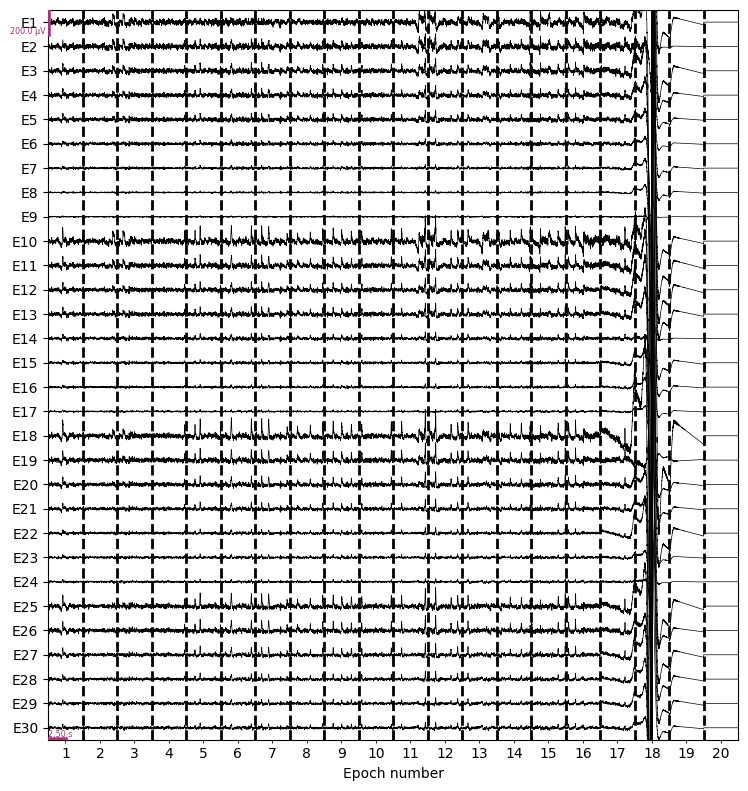

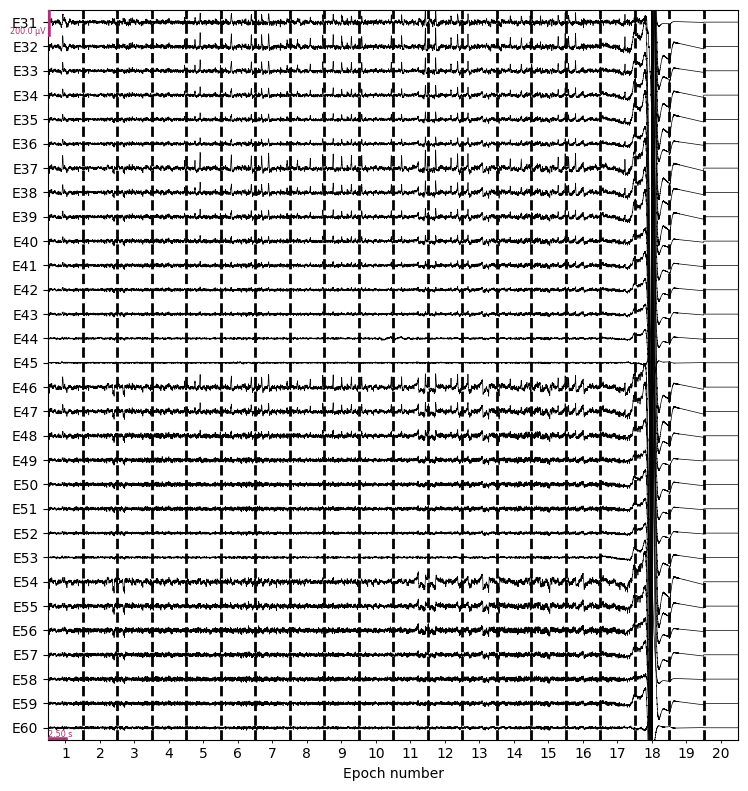

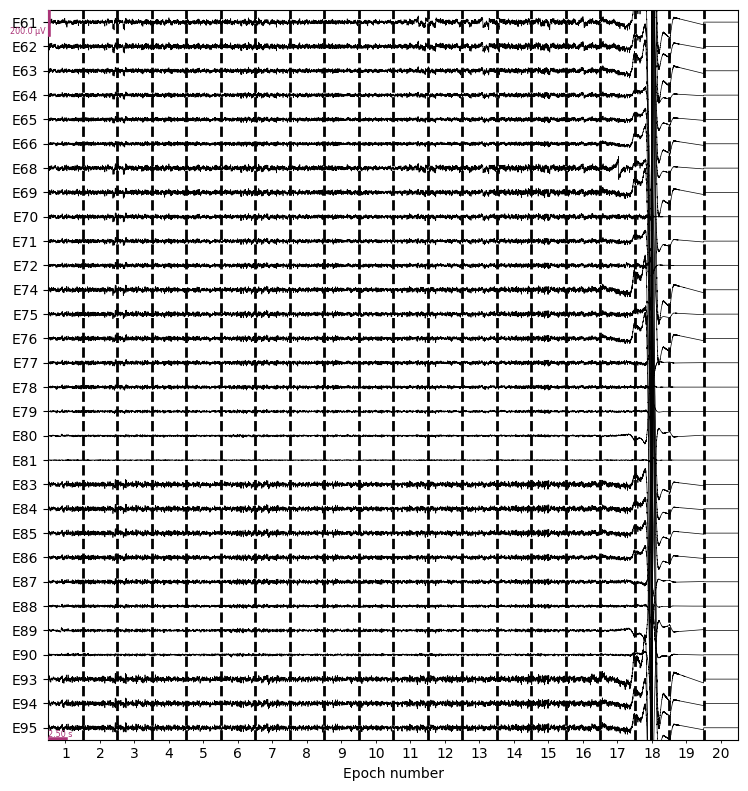

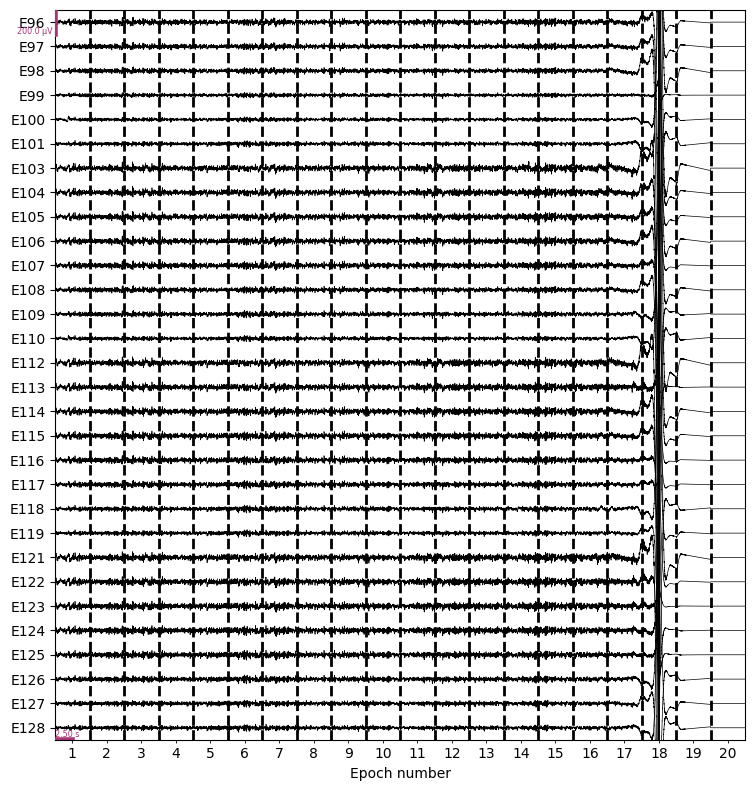

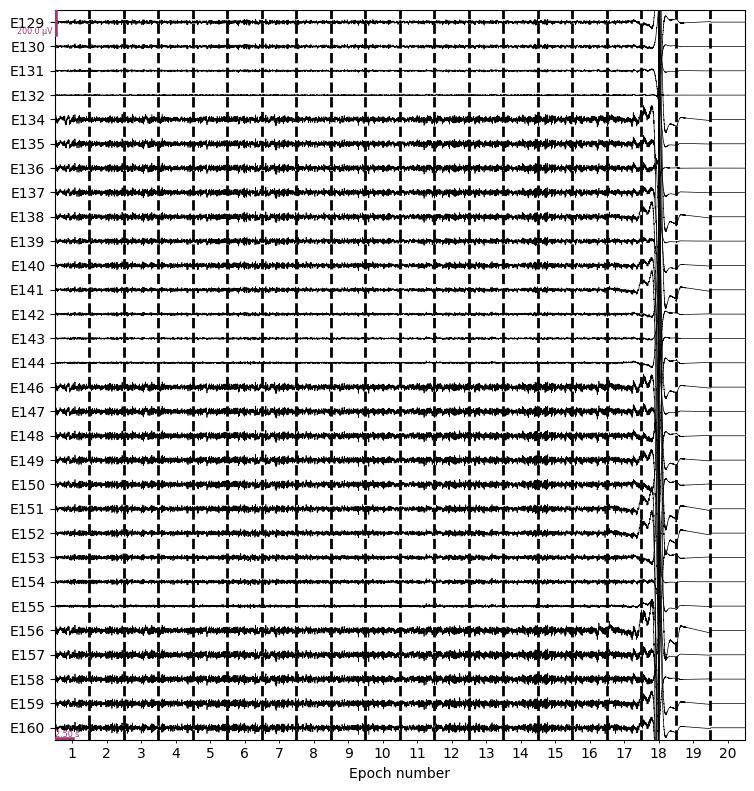

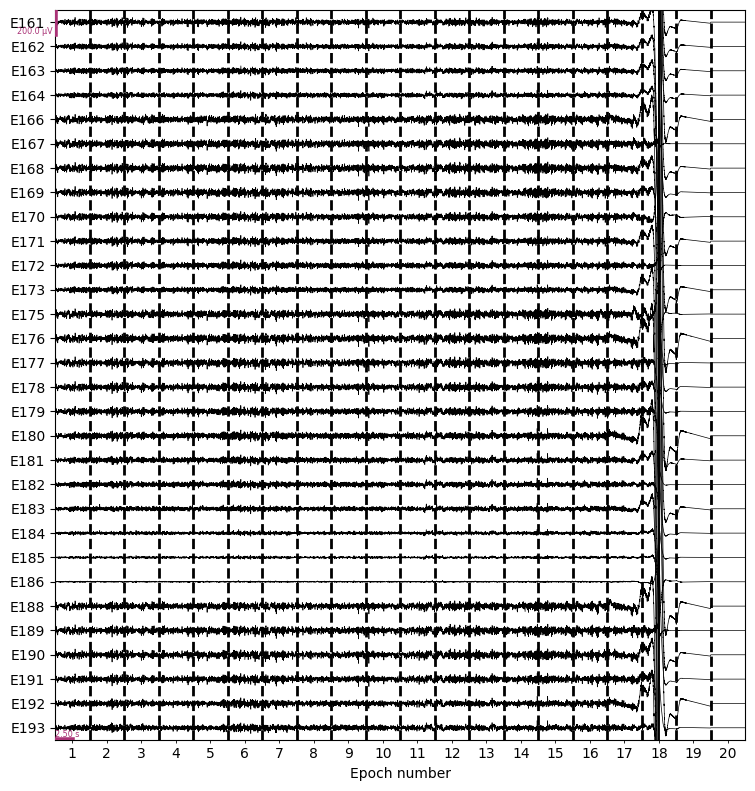

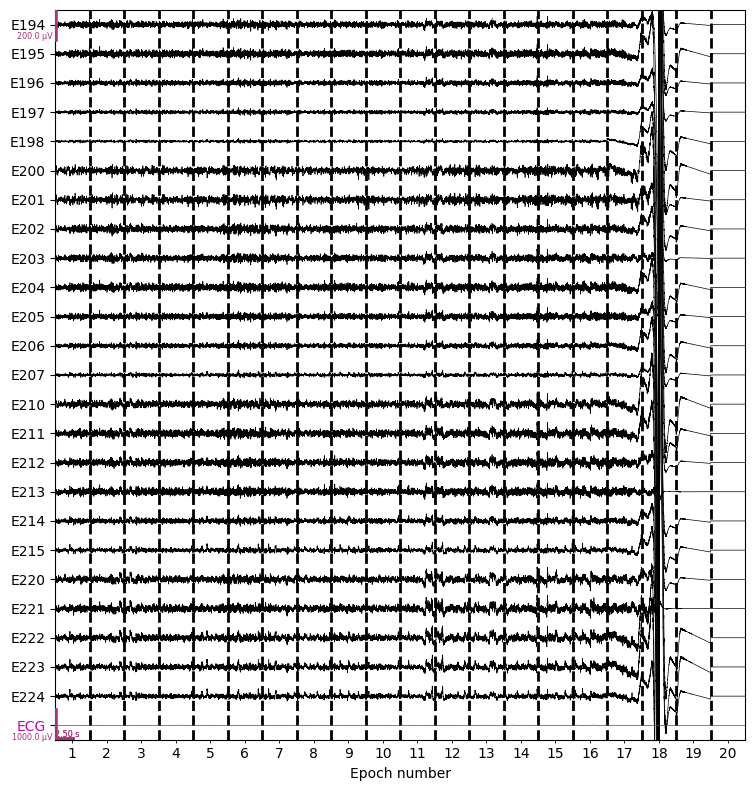

In [17]:
# Assuming 'raw' is your MNE raw object
# Get the list of all channels
all_channels = epochs.info["ch_names"]

# Get the list of bad channels
bad_channels = epochs.info["bads"]

# Get the list of good channels
good_channels = [ch for ch in all_channels if ch not in bad_channels]

# Get the indices of the good channels
good_channels_indices = [all_channels.index(ch) for ch in good_channels]

# Define the chunk size
chunk_size = 30

# Create chunks of the good channels
chunks = [
    good_channels_indices[i : i + chunk_size]
    for i in range(0, len(good_channels_indices), chunk_size)
]

if n_bad_epochs > 0 :
    # Now you can iterate over the chunks
    for chunk in chunks:
        # Do something with the chunk
        # print(chunk)
        mne.viz.plot_epochs(
            epochs=epochs[reject_log.bad_epochs],
            picks=chunk,
            show=False,
            scalings=dict(eeg=1e-4),
            n_channels=chunk_size,
            show_scrollbars=False,
        )

In [15]:
print(f"Sub{subject_id} -  removed {sum(reject_log.bad_epochs)} epochs")
print(f"Sub{subject_id} -  retained {len(epochs[~reject_log.bad_epochs])} epochs")

epochs_good = epochs[~reject_log.bad_epochs]
epochs_good.save(
    f"{paths.epochs}/sub-{subject_id}_good_epochs-epo.fif", overwrite=True
)

Sub127 -  removed 87 epochs
Sub127 -  retained 0 epochs
Overwriting existing file.
Overwriting existing file.
Overwriting existing file.


/var/folders/xq/sl7xjp_95qx7wfngy6s6vvg00000gn/T/ipykernel_22208/1029766826.py:5: RuntimeWarning: Saving epochs with no data
  epochs_good.save(
/var/folders/xq/sl7xjp_95qx7wfngy6s6vvg00000gn/T/ipykernel_22208/1029766826.py:5: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  epochs_good.save(


[PosixPath('/Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-127/epochs/sub-127_good_epochs-epo.fif')]